******A COMPREHENSIVE STUDY ON THE IMPACT OF ECONOMIC FACTORS ON PASSENGER VEHICLE SUPPLY AND DEMAND IN THE UNITED STATES THROUGH TIME SERIES ANALYSIS******

****Introduction****

During the late-1800’s to early 1900’s, the United States entered the era of the Industrial Revolution. This would be a period defined by new technological innovations and the expansion of large corporations and monopolies. One such development that came out of this era was the automobile. With the invention and expansion of the automobile industry, the United States would subsequently develop their infrastructure around this, embedding automobiles as a foundational core to the American way of life. Today, we continue to see the effects of this, from the development of the interstate highway system to the way cities and suburbs are built around cars. Considering the prolific role that vehicles occupy in the US, this analysis aims to examine the expansion of supply and demand in the automobile industry at the turn of the 21st century to today. The analysis plan will review the existing literature on the topic and study various factors that create (or reduce) demand.  The goal is to understand how these factors drive the automobile economy as well as how it could affect future demand and supply.

****Analysis****

**1. Import packages, datasets and Merging datasets**

In [10]:
!pip install arch

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import itertools

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='statsmodels')
warnings.filterwarnings("ignore", category=RuntimeWarning, module='statsmodels')
warnings.filterwarnings("ignore", category=FutureWarning, module='statsmodels')
# Load the data path folder
# This might need to be generalized if people use desktop vs cloud, where we specify a variable like filepath
# DATA_PATH = os.chdir("/content/drive/MyDrive/ISYE-6402 Final Project/Analysis_Notebooks/Approach 1")



In [12]:
#Monthly
sales = pd.read_csv("Sales.csv")
interest_rate = pd.read_csv("Interest rates.csv")
cpi = pd.read_csv("CPI.csv")
disposable_income = pd.read_csv("Disposable income.csv")
auto_prod = pd.read_csv("Auto_production.csv")
unemp_rate = pd.read_csv("Unemployment rate.csv")
gas_prices = pd.read_csv("Gas prices.csv")


#Quarterly
GDP = pd.read_csv("GDP.csv")
imports = pd.read_csv("Imports.csv")
financing_rate = pd.read_csv("Financing auto loan rate.csv")

#Yearly
inflation = pd.read_csv("Inflation2.csv")

#Merging data (Monthly only)
merged_df = pd.merge(sales, interest_rate, left_on= 'Date', right_on = 'observation_date', how='outer').merge(cpi, on='observation_date')\
            .merge(disposable_income, on='observation_date').merge(auto_prod, on='observation_date')\
            .merge(unemp_rate, on='observation_date').merge(gas_prices, on='Date', how='outer')
merged_df
merge_df = merged_df.drop(columns=['observation_date'])
merge_df

#Renaming column names
df = merge_df.rename(columns={'Mn dollars': 'Mn units', 'FEDFUNDS %': 'Interest_rate', \
                              'CUSR0000SETA':'cpi', 'DSPIC96':'disposable_income($)', 'DAUPSA':'auto_production("000 units)',\
                              'UNRATE':'unempl_rate','Dollar per gallon':'gas_price(gallon)'})
df


,Date,Mn units,Interest_rate,cpi,disposable_income($),"auto_production(""000 units)",unempl_rate,gas_price(gallon)
0,2000-01-01,18.635,5.45,100.4,9799.9,469.3,4.0,1.329
1,2000-02-01,19.401,5.73,100.0,9837.9,461.2,4.1,1.415
2,2000-03-01,18.343,5.85,100.2,9864.0,462.3,4.0,1.556
3,2000-04-01,17.939,6.02,100.5,9913.7,475.4,3.8,1.506
4,2000-05-01,17.943,6.27,100.9,9954.5,481.2,4.0,1.526
...,...,...,...,...,...,...,...,...
308,2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,3.293
309,2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,3.190
310,2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,3.179
311,2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,3.024


**2. Data Modeling on Sales**

*2a. Exploratory Data Analysis*

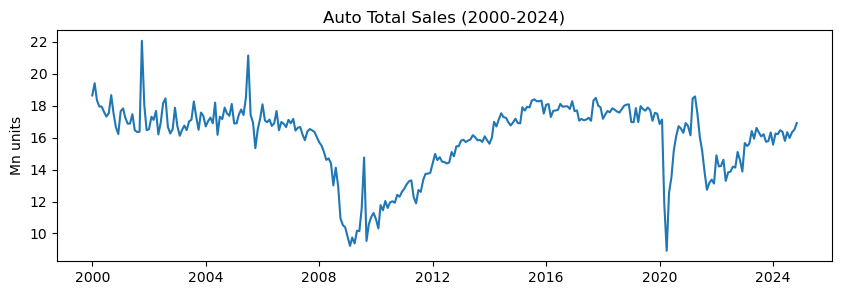

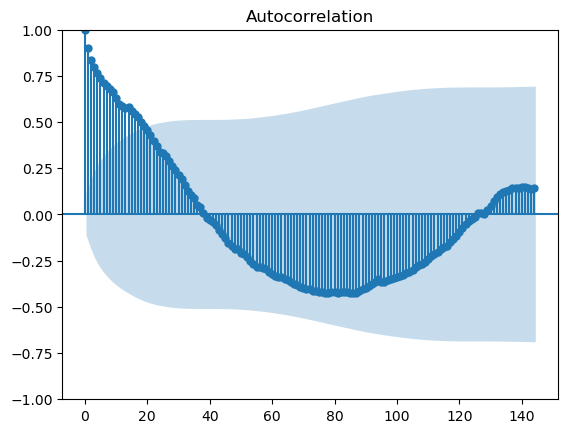

In [13]:
#Sales data plotting
df['Date'] = pd.to_datetime(df['Date'][0:299])
plt.figure(figsize=(10,3))
plt.plot(df['Date'][0:299], df['Mn units'][0:299])
plt.title("Auto Total Sales (2000-2024)")
plt.ylabel("Mn units")
plt.show()
plot_acf(df['Mn units'][0:299], lags=144)
plt.show()

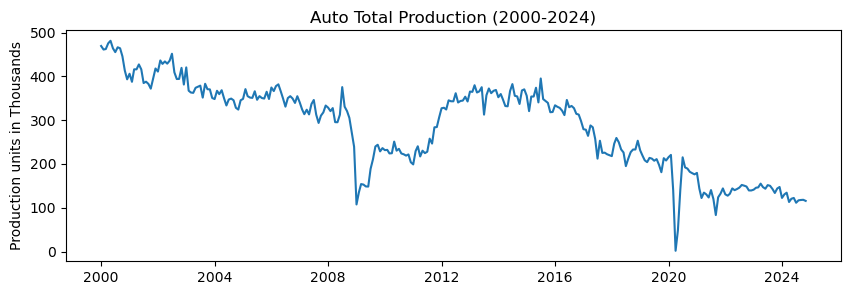

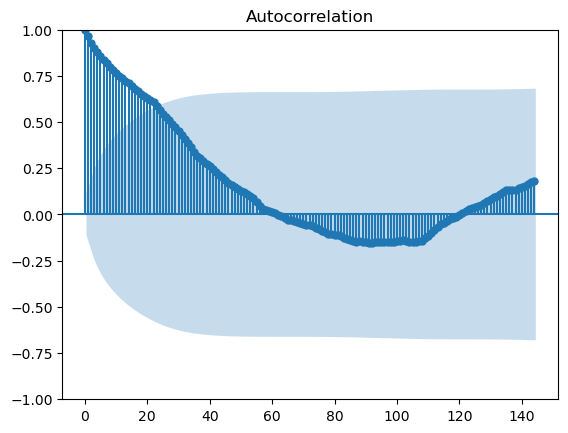

In [14]:
#Production data plotting
df['Date'] = pd.to_datetime(df['Date'][0:299])
plt.figure(figsize=(10,3))
plt.plot(df['Date'][0:299], df['auto_production("000 units)'][0:299])
plt.title("Auto Total Production (2000-2024)")
plt.ylabel("Production units in Thousands")
plt.show()
plot_acf(df['auto_production("000 units)'][0:299], lags=144)
plt.show()

Corr production/Sales: 0.4386028671907666


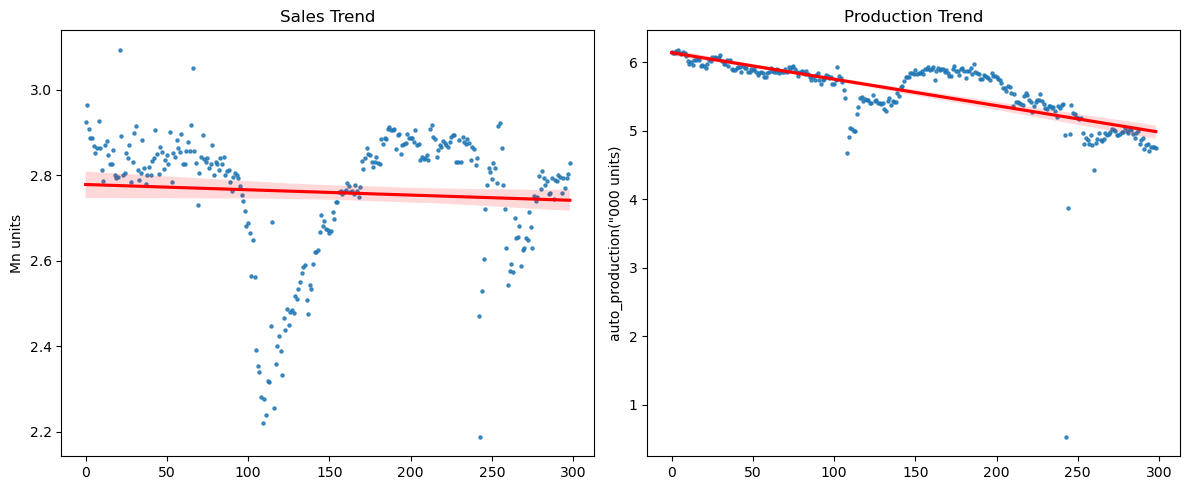

In [15]:
#Correlation producton and sales
c = df['auto_production("000 units)'].corr(df['Mn units'])
log_sales = np.log(df['Mn units'][0:299])
log_prod = np.log(df['auto_production("000 units)'][0:299])
print("Corr production/Sales:", c)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(x=df['Mn units'][0:299].index, y=log_sales, scatter_kws={'s': 5}, label='Sales', ax=axes[0],line_kws=dict(color='red'))
sns.regplot(x=df['auto_production("000 units)'][0:299].index, y=log_prod, scatter_kws={'s': 5}, label='Production',
            ax=axes[1], line_kws=dict(color='red'))

axes[0].set_title('Sales Trend')
axes[1].set_title('Production Trend')

plt.tight_layout()
plt.show()


There is declining trend in both sales and production. Although, demand of vehicles has declined steadily over time whereas production has significant downward shift signifying lower production units. We can look at Imports data to see if the decline has any thing to do with focus on import policies and startegies.  

Correlation: -0.5533138969794092


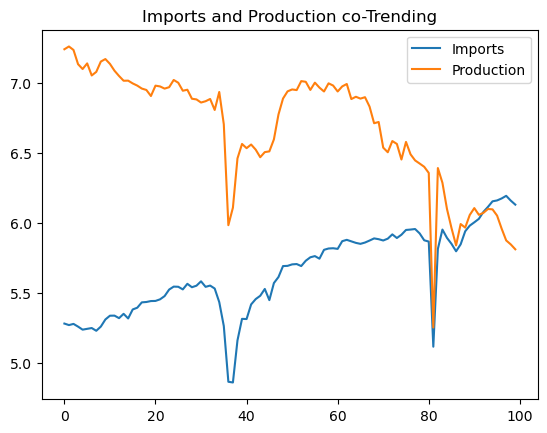

In [16]:
#Converting monthly data production to quarterly data
auto_prod['observation_date'] = pd.to_datetime(auto_prod['observation_date'])
prod_qtr = auto_prod.set_index('observation_date')
imports['new_date'] = pd.to_datetime(imports['observation_date'])

prod_qtr = prod_qtr.resample('QS').sum()
prod_qtr = prod_qtr.reset_index()

merge_prod_imports = prod_qtr.merge(imports, left_on='observation_date', right_on='new_date').rename(columns={'DAUPSA':'Production','B651RC1Q027SBEA':'Imports'})
corr_ip = merge_prod_imports['Production'].corr(merge_prod_imports['Imports'])
print("Correlation:", corr_ip)
imp = np.log(pd.Series(merge_prod_imports['Imports']))
prod = np.log(pd.Series(merge_prod_imports['Production']))
plt.plot(imp, label='Imports')
plt.plot(prod, label='Production')
plt.title("Imports and Production co-Trending")
plt.legend()
plt.show()


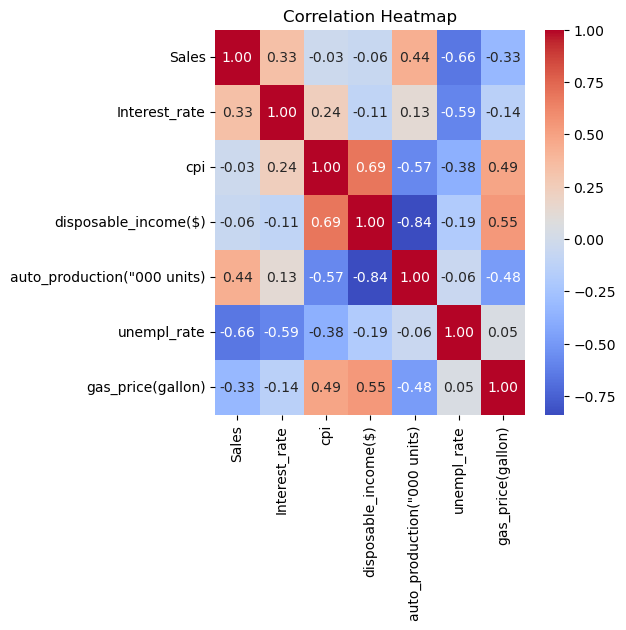

In [17]:
corr = df.drop(columns=['Date']).rename(columns={'Mn units':'Sales'}).corr()
plt.figure(figsize=(5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()



Interest rates and production have positive medium correlation with sales. Cpi and disposable income have no impact on sales of vehicles. Unemployment is the only variable that (as compared to other variables) significantly impact sales. Gas prices also dictate buying behaviour to some extent.  

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[['Interest_rate','cpi','disposable_income($)',
        'auto_production("000 units)','unempl_rate','gas_price(gallon)']]

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values[0:299], i) for i in range(X.shape[1])]

print(vif)

                      Variable         VIF
0                Interest_rate    3.352257
1                          cpi  202.120799
2         disposable_income($)  123.533947
3  auto_production("000 units)   12.070695
4                  unempl_rate   11.677328
5            gas_price(gallon)   19.392027


cpi and disposable income moderately correlated and we can keep one. Disposable income is being kept. Gas price and disposable income also partially correlated and thus gas prices seems to have similar impact on sales as disposable income and is likely derived from disposable income and not vice versa. Unemployment is has significant negative correlation with sales, but so does it have with interest rate (-0.59). Interest rates we have seen have significant negative impact on sales as well. So, we can keep one of these variables. Interest rate is premise of all economic activities so let's keep that one and remove unemployment rate from our analysis for simplicity.  
Final variables to be kept: Disposable income and Interest rate.
**Removed variables: Gas prices, unemployment rate, cpi**

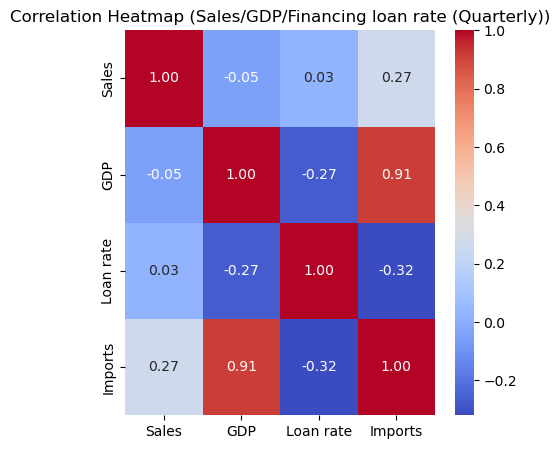

In [19]:
#Converting monthly data sales to quarterly data
sales['Date'] = pd.to_datetime(sales['Date'])
sales_qtr = sales.set_index('Date')

sales_qtr = sales_qtr.resample('QS').sum()
sales_qtr = sales_qtr.reset_index()
gdp_new = GDP[212:-3]
gdp_new = gdp_new.reset_index(drop=True)
merge_gdp_sales = sales_qtr.join(gdp_new)
merge_fn_gdp_sales = merge_gdp_sales.merge(financing_rate, on='observation_date').merge(imports, on='observation_date')\
                      .rename(columns={'B651RC1Q027SBEA':'Imports'})
merge_fn_gdp_sales = merge_fn_gdp_sales.drop(columns=['observation_date'])

corr_fn_gdp_sales = pd.DataFrame(merge_fn_gdp_sales[['Mn dollars','GDP','Loan rate','Imports']])
corr_fn_gdp_sales = corr_fn_gdp_sales.rename(columns={'Mn dollars': 'Sales'})
corr_df = corr_fn_gdp_sales.corr()


plt.figure(figsize=(5, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap (Sales/GDP/Financing loan rate (Quarterly))")
plt.show()


Correlation financiang rate / interest rate): 0.74


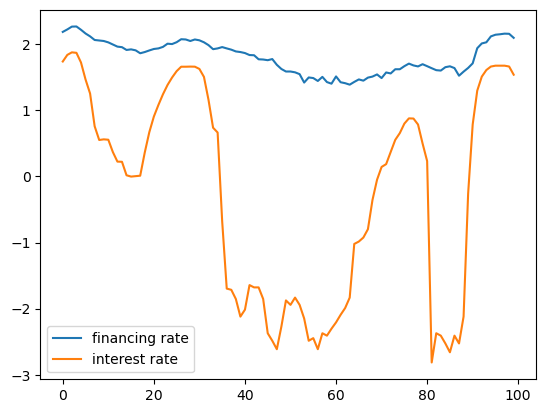

In [20]:


interest_rate['observation_date'] = pd.to_datetime(interest_rate['observation_date'])
int_qtr = interest_rate.set_index('observation_date')

int_qtr = int_qtr.resample('QE').mean()
int_qtr = int_qtr.reset_index()

print("Correlation financiang rate / interest rate):", round(np.log(int_qtr['FEDFUNDS %'][0:100]).corr(np.log(financing_rate['Loan rate'])),2))
plt.plot(np.log(financing_rate['Loan rate']), label='financing rate')
plt.plot(np.log(int_qtr['FEDFUNDS %'][0:100]), label='interest rate')
plt.legend()
plt.show()


Negligible impact of loan rate and GDP on sales (demand). Also GDP and imports have very high correlation. So GDP can be removed. Imports have some positive impact on sales. More imports influences more sales. Loan rate and interest rate have significant correlation and thus, we can keep one. Loan rate can also be seen to have negligible relationship with sales.
**Variable to be kept: Imports**

In [21]:
#Converting monthly data sales to yearly data
sales['Date'] = pd.to_datetime(sales['Date'])
sales_yr = sales.set_index('Date')

sales_yr = sales_yr.resample('YS').sum()
sales_yr = sales_yr.reset_index()
sales_yr
merge_inf_sales = sales_yr.join(inflation)
merge_inf_sales.drop(columns=['observation_date'])
corr_infl_sales = round(merge_inf_sales['Mn dollars'].corr(merge_inf_sales['Percentage']),2)
print("Correlation (inflation/SALES):", corr_infl_sales)

Correlation (inflation/SALES): -0.01


No impact of inflation on sales. Inflation is also controlled by Interest rates and thus, inflation is removed from considered variables for further analysis.

**Final economic independent variables:**
1. Interest rates
2. Disposable income
3. Imports

**Dependent variables:**
1. Sales
2. Production

In [22]:
def adf_test(series):
    result = adfuller(series.dropna())
    return result[1]  # p-value

print("ADF TEST - SALES:", adf_test(df['Mn units'][0:299]))
print("ADF TEST - PRODUCTION:", adf_test(df['auto_production("000 units)']))


ADF TEST - SALES: 0.04477696783552572
ADF TEST - PRODUCTION: 0.5133983660762503


Sales is stationary with constant mean and variance. Production data is not stationary, however since sales pvalue is also closer to 0.05, we will difference both series.

Ljungbox-test:
      lb_stat  lb_pvalue
10  18.936368   0.041078
ADF TEST - diff sales: 1.4970049686960508e-28


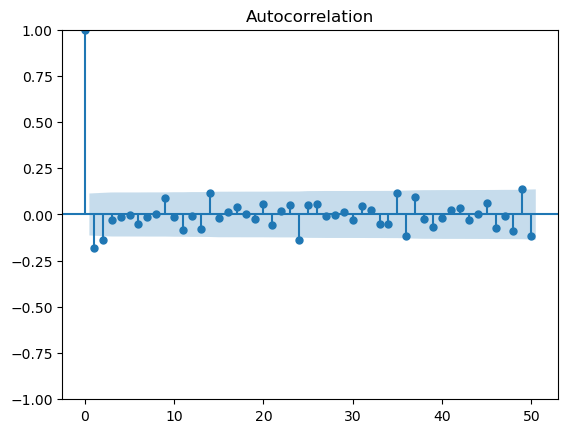

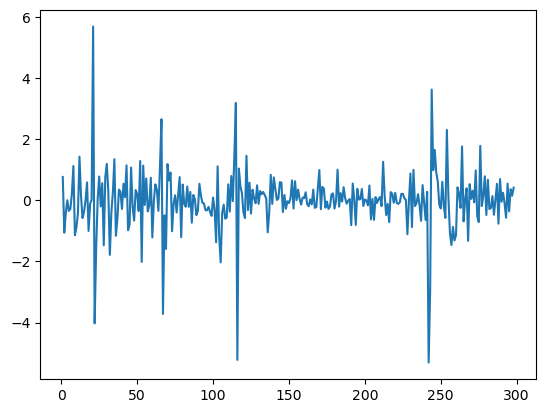

In [23]:
#Differenced sales data
diff_sales= df['Mn units'][0:299].diff(1).dropna()

print("Ljungbox-test:")
lb_test = acorr_ljungbox(diff_sales, lags=[10], return_df=True)
print(lb_test)
print("ADF TEST - diff sales:", adf_test(diff_sales))

plot_acf(diff_sales, lags=50)
plt.show()
plt.plot(diff_sales)
plt.show()

Ljungbox-test:
      lb_stat  lb_pvalue
10  13.936208   0.175921
ADF TEST - diff prod: 7.35601763638814e-24


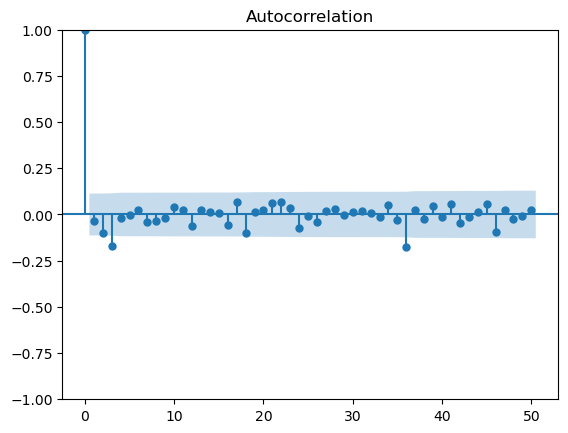

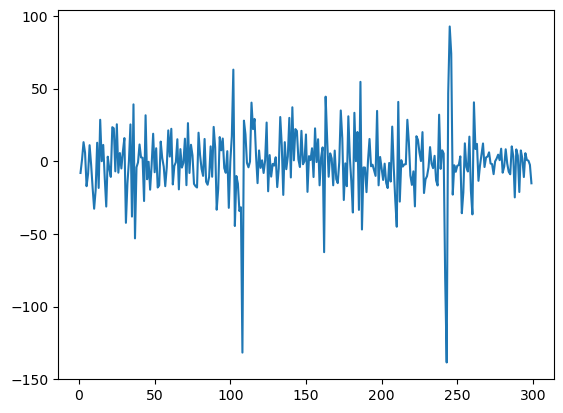

In [24]:
#Differenced production data
diff_prod= df['auto_production("000 units)'].diff(1).dropna()
print("Ljungbox-test:")
lb_test = acorr_ljungbox(diff_prod, lags=[10], return_df=True)
print(lb_test)
print("ADF TEST - diff prod:", adf_test(diff_prod))

plot_acf(diff_prod, lags=50)
plt.show()

plt.plot(diff_prod)
plt.show()



Trend is removed but variance remains. ARIMA-GARCH model is proposed.

### **2a. Model fitting**

In [25]:
#Train / test split Sales
train_size = int(len(df['Mn units'][0:299]) * 0.9)
train_sales = df['Mn units'][0:299].iloc[:train_size]
test_sales = df['Mn units'][0:299].iloc[train_size:]




In [26]:
#ARIMA Model selection based on best aic
def arima_search(series):

    results = []

    for p, d, q in itertools.product(range(6), [1,2], range(6)):
        try:
            model = ARIMA(series, order=(p,d,q))
            fit = model.fit()

            results.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": fit.aic,
                "model": fit
            })

        except:
            continue

    results_df = pd.DataFrame(results)

    best_row = results_df.loc[results_df["AIC"].idxmin()]

    return best_row

In [27]:
# Best model fit on train data
best_sales_arima = arima_search(train_sales)

print("Best ARIMA Model:")
print("ARIMA(",best_sales_arima.p,",",best_sales_arima.d,",",best_sales_arima.q,")")

print(best_sales_arima.model.summary())

Best ARIMA Model:
ARIMA( 1 , 1 , 1 )
                               SARIMAX Results                                
Dep. Variable:               Mn units   No. Observations:                  269
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -369.650
Date:                Wed, 13 May 2026   AIC                            745.301
Time:                        10:19:48   BIC                            756.074
Sample:                             0   HQIC                           749.628
                                - 269                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5349      0.074      7.245      0.000       0.390       0.680
ma.L1         -0.7867      0.069    -11.394      0.000      -0.922      -0.651
sigma2         

In [28]:
#Checking for volatility
arima_sales = ARIMA(train_sales, order=(1,0,0))
sales_fit = arima_sales.fit()
mean_forecast_sales = sales_fit.forecast(steps=len(test_sales))
residuals_sales = sales_fit.resid

from statsmodels.stats.diagnostic import het_arch

test = het_arch(residuals_sales)
print("lm_pvalue:", test[1])
print("f_pvalue:", test[3])


lm_pvalue: 0.004225031764233102
f_pvalue: 0.003373370693942368


Both p values are below 0.05. ARIMA is not sufficient for capturing the volatility, GARCH model is required.

In [29]:
from arch import arch_model

garch_sales = arch_model(residuals_sales, vol='Garch', p=1, q=1)
garch_fit_sales = garch_sales.fit()
print(garch_fit_sales.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1012.8876859719637
Iteration:      2,   Func. Count:     14,   Neg. LLF: 309999.4630264374
Iteration:      3,   Func. Count:     20,   Neg. LLF: 421.7461371299793
Iteration:      4,   Func. Count:     26,   Neg. LLF: 350.9086277364749
Iteration:      5,   Func. Count:     31,   Neg. LLF: 350.9138694828488
Iteration:      6,   Func. Count:     37,   Neg. LLF: 350.87444838371755
Iteration:      7,   Func. Count:     42,   Neg. LLF: 350.8742111873537
Iteration:      8,   Func. Count:     46,   Neg. LLF: 350.87421124659124
Optimization terminated successfully    (Exit mode 0)
            Current function value: 350.8742111873537
            Iterations: 8
            Function evaluations: 46
            Gradient evaluations: 8
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared: 

### **2b. Forecasting with ARIMA-GARCH**

In [ ]:
#Forecast GARCH Model
vol_forecast_sales = garch_fit_sales.forecast(horizon=len(test_sales))
volatility = np.sqrt(vol_forecast_sales.variance.values[-1,:])


# #Upper and Lower bounds with ARIMA mean forecast
upper = mean_forecast_sales + 1.96 * volatility
lower = mean_forecast_sales - 1.96 * volatility



269    15.886651
270    15.881536
271    15.993116
272    16.144078
273    16.300907
274    16.450831
275    16.589686
276    16.716653
277    16.832132
278    16.936929
279    17.031942
280    17.118051
281    17.196077
282    17.266773
283    17.330828
284    17.388862
285    17.441443
286    17.489083
287    17.532245
288    17.571351
289    17.606782
290    17.638883
291    17.667967
292    17.694318
293    17.718192
294    17.739823
295    17.759421
296    17.777177
297    17.793264
298    17.807839
Name: predicted_mean, dtype: float64

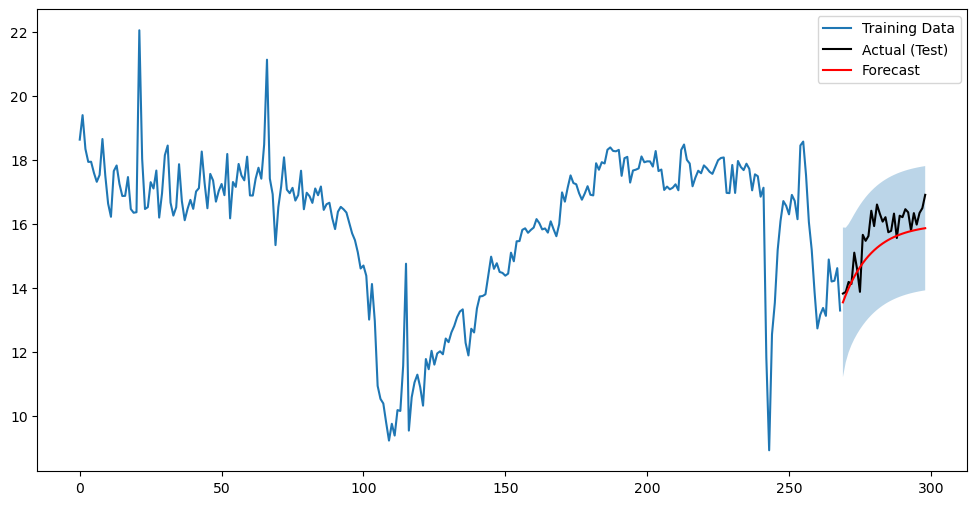

In [46]:
#Predictions
plt.figure(figsize=(12,6))

# Training data
plt.plot(train_sales.index, train_sales, label="Training Data")

# Actual test data
plt.plot(test_sales.index, test_sales, label="Actual (Test)", color="black")

# Forecast
plt.plot(test_sales.index, mean_forecast_sales, label="Forecast", color="red")

# Confidence Interval
plt.fill_between(mean_forecast_sales.index, lower, upper, alpha=0.3)
plt.legend()
plt.show()


### **2c. Model Performance evaluation**

In [47]:
#MAPE, MAE, & RMSE
mape_sales = np.mean(np.abs((test_sales.values - mean_forecast_sales) / test_sales.values)) * 100
mae_sales = np.mean(np.abs(test_sales.values - mean_forecast_sales))
rmse_sales = np.sqrt(np.mean((test_sales.values - mean_forecast_sales) ** 2))
print(f"MAPE: {mape_sales:.2f}%")
print("MAE:", mae_sales)
print("RMSE:", rmse_sales)

MAPE: 3.52%
MAE: 0.5611071274514896
RMSE: 0.664867747087246


MAPE is 3.52% which is excellent and shows that model is quite accurate in terms of forecasting. MAE and RMSE suggest stable predictions with no significant outliers.

### **2d. VAR Model**

In [48]:
#converting disposable income into quarterly frequency
disposable_income['observation_date'] = pd.to_datetime(disposable_income['observation_date'])
dp_qtr = disposable_income.set_index('observation_date')

dp_qtr = dp_qtr.resample('QE').mean()
dp_qtr = dp_qtr.reset_index()


In [49]:
#Creating dataframe
var_sales = pd.DataFrame({
    'sales': sales_qtr['Mn dollars'],
    'imports': imports['B651RC1Q027SBEA'],
    'disposable_income': dp_qtr['DSPIC96'],
    'interest_rate': int_qtr['FEDFUNDS %']
}).dropna()



In [50]:
#Checking stationarity
def adf_test(series):
    result = adfuller(series)
    print(f'p-value: {result[1]}')

for col in var_sales.columns:
    print(col)
    adf_test(var_sales[col])

sales
p-value: 0.09162874478657557
imports
p-value: 0.761017938623912
disposable_income
p-value: 0.9929222618695817
interest_rate
p-value: 0.000864345355432975


All the pvalues except interest rate are above 0.05 and hence non-stationary. Thus, we will difference the data.

In [51]:
var_sales_diff = var_sales.diff().dropna()

#Model VAR
model = VAR(var_sales_diff)

# Select optimal lag
lag_results = model.select_order(maxlags=10)
print(lag_results.summary())

# Fitting model using AIC
lag = lag_results.aic
var_model = model.fit(lag)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        18.02       18.13   6.708e+07       18.07
1        17.01      17.57*   2.431e+07       17.23
2        16.96       17.96   2.317e+07       17.36
3       16.52*       17.98  1.511e+07*      17.11*
4        16.57       18.47   1.594e+07       17.33
5        16.57       18.91   1.622e+07       17.51
6        16.67       19.46   1.839e+07       17.79
7        16.83       20.07   2.245e+07       18.14
8        16.97       20.66   2.721e+07       18.46
9        17.05       21.19   3.143e+07       18.72
10       17.11       21.70   3.645e+07       18.96
--------------------------------------------------


In [52]:
#Testing whether indicators help predict sales
caus_sales = var_model.test_causality('sales', ['imports', 'disposable_income', 'interest_rate'], kind='f')

print(caus_sales.summary())

Granger causality F-test. H_0: ['imports', 'disposable_income', 'interest_rate'] do not Granger-cause sales. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
         4.168          1.908   0.000 (9, np.int64(332))
--------------------------------------------------------


The Granger-causality test shows that p-value is 0 and this means economic indicators do impact sales.

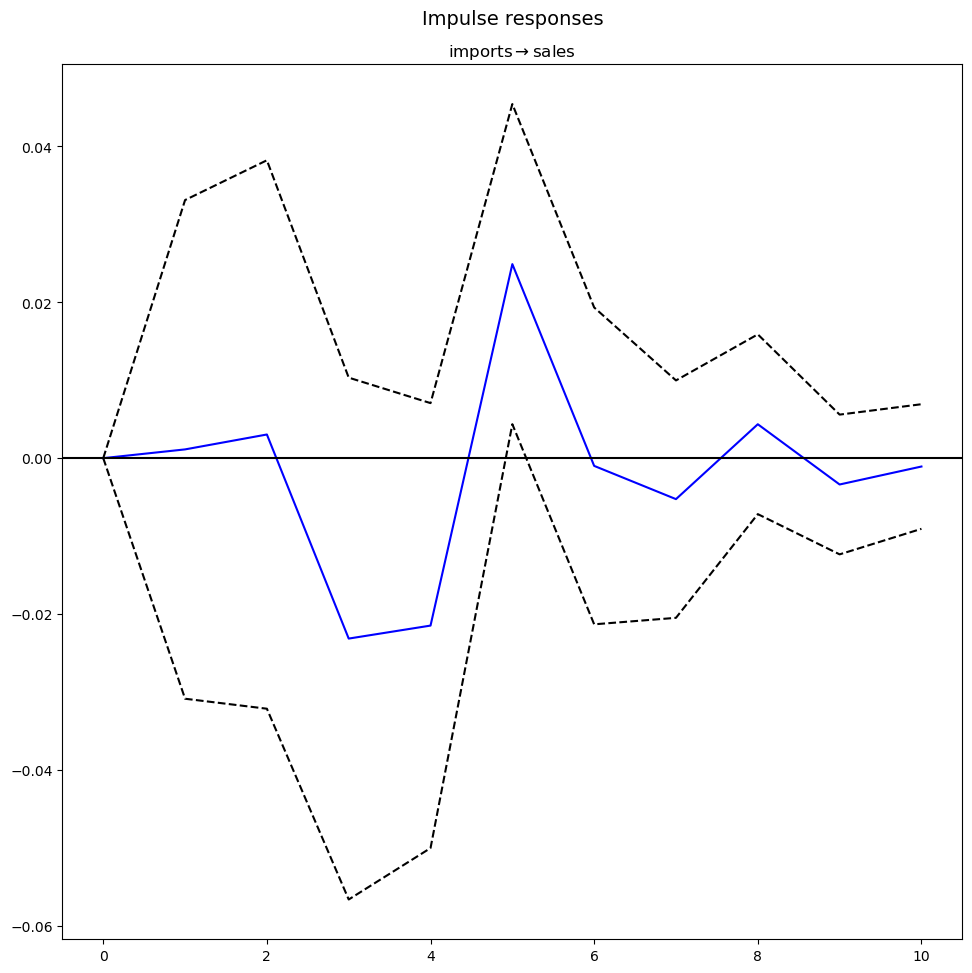

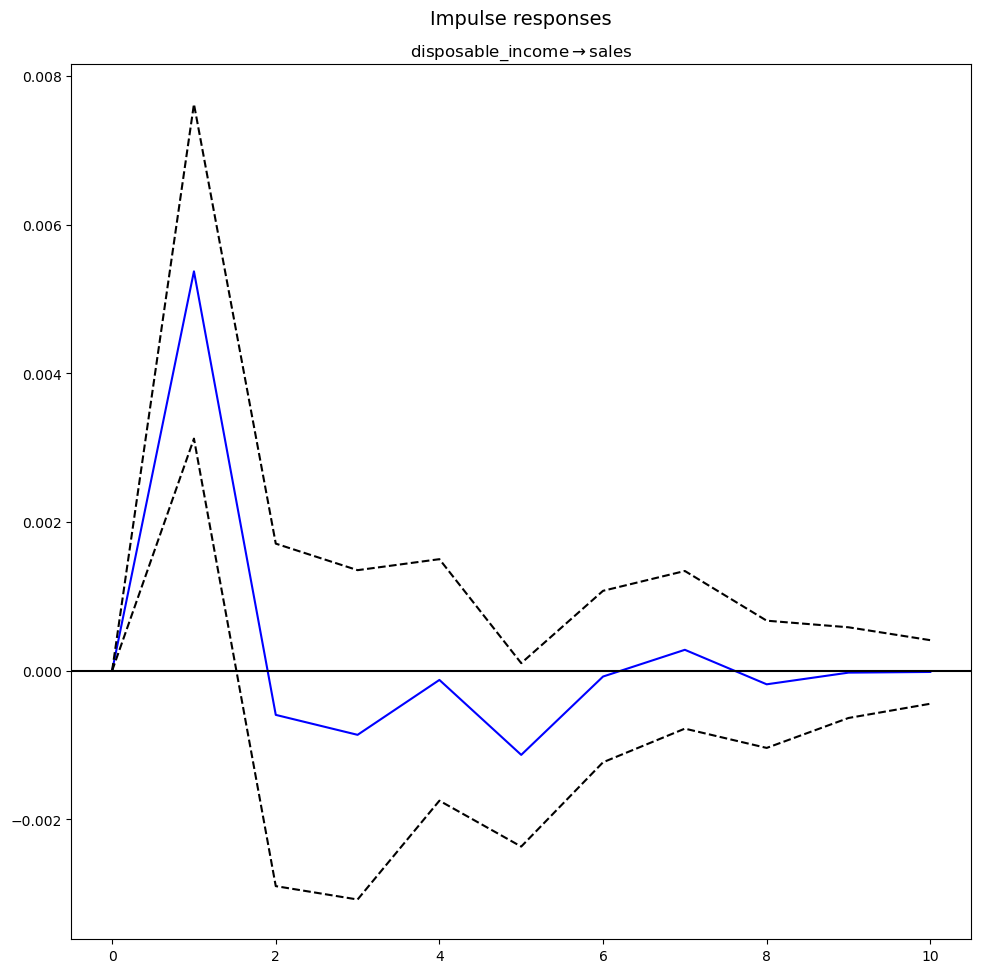

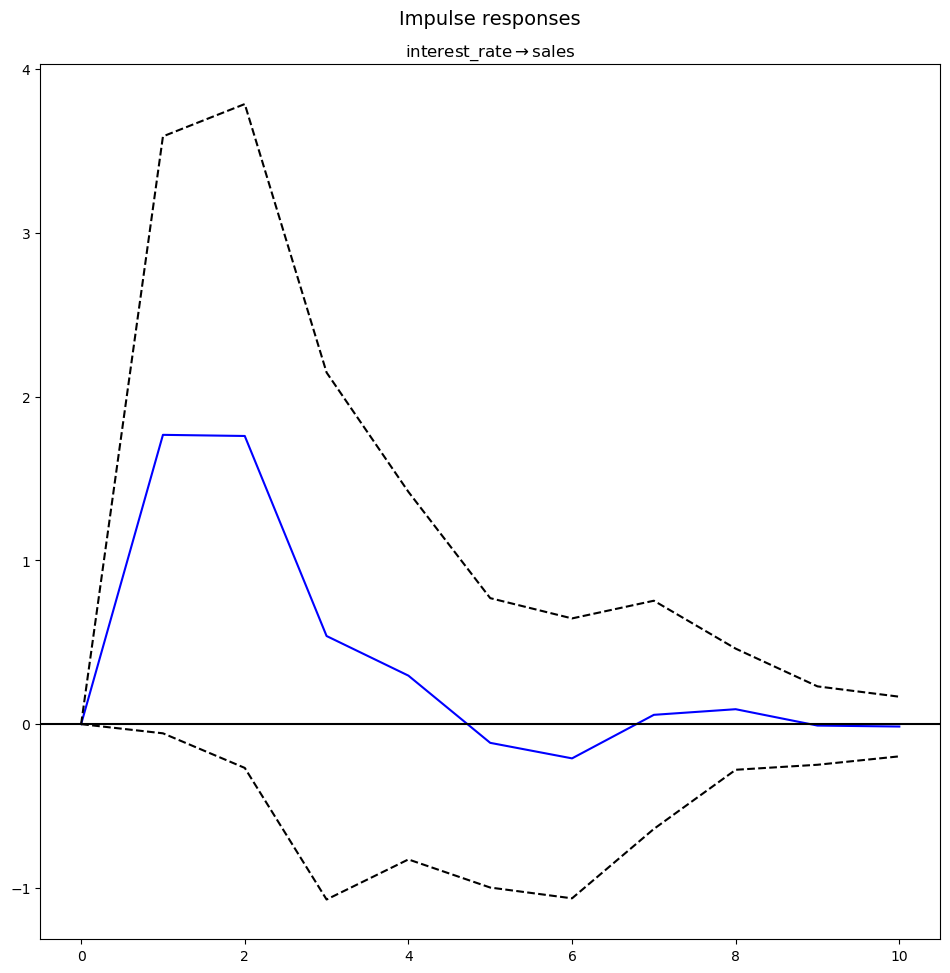

In [53]:
#checking response of economic indicators on sales
irf = var_model.irf(10)

for var in ['imports', 'disposable_income', 'interest_rate']:
    irf.plot(impulse=var, response='sales')

The imports shock have a declining effect on sales in short term, but gradually increases impact before having negligible impact. The disposable income and interest rate have increasing effect on sales initially but it is short lived and becomes negligible in long term.

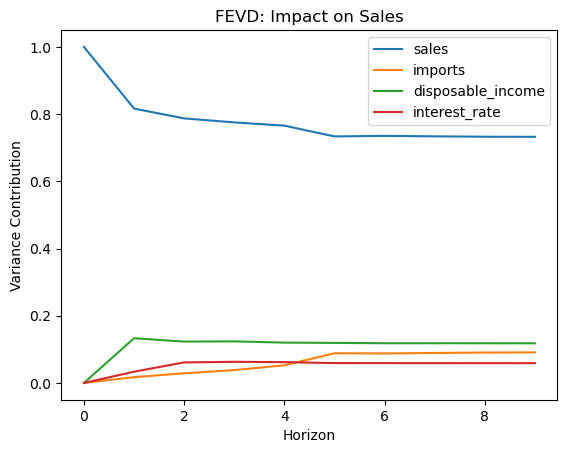

In [54]:
#Computing fevd for all economic indicators to check the extent of influence on sales.
fevd = var_model.fevd(10)
sales_idx = var_model.names.index('sales')
sales_fevd = fevd.decomp[sales_idx]
import matplotlib.pyplot as plt

for i, var in enumerate(var_model.names):
    plt.plot(sales_fevd[:, i], label=var)

plt.title("FEVD: Impact on Sales")
plt.xlabel("Horizon")
plt.ylabel("Variance Contribution")
plt.legend()
plt.show()

Forecast error variance decomposition shows that sales dominantly vary by its own shocks than economic indicators. Those external indiscators only contribute around 20% of variability. Among these, imports have a gradual increase in influence over time, but disposable income and interest rate have only short-term and limited effects. This hints that there might be other factors like seasonality, pricing, marketing, etc. that is influencing sales rather than economic variables.
**Final takeaway:** Macroeconomic variables are not strong drivers of sales in this dataset.

# **3. Data Modeling on Production**

In [55]:
#Train / test split Production
train_p = int(len(df['auto_production("000 units)'][0:299]) * 0.9)
train_prod = df['auto_production("000 units)'][0:299].iloc[:train_p]
test_prod = df['auto_production("000 units)'][0:299].iloc[train_p:]

### **3a. Model fitting**

In [56]:
# Best model fit on train data
best_prod_arima = arima_search(train_prod)

print("Best Production Model:")
print("ARIMA(",best_prod_arima.p,",",best_prod_arima.d,",",best_prod_arima.q,")")

print(best_prod_arima.model.summary())

Best Production Model:
ARIMA( 0 , 2 , 4 )
                                    SARIMAX Results                                    
Dep. Variable:     auto_production("000 units)   No. Observations:                  269
Model:                          ARIMA(0, 2, 4)   Log Likelihood               -1222.276
Date:                         Wed, 13 May 2026   AIC                           2454.552
Time:                                 10:27:23   BIC                           2472.488
Sample:                                      0   HQIC                          2461.757
                                         - 269                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0754      5.027     -0.214      0.831     -10.929       8.778
ma.L2         -0.

In [57]:
#Checking for volatility
arima_prod = ARIMA(train_prod, order=(0,2,4))
prod_fit = arima_prod.fit()
mean_forecast_prod = prod_fit.forecast(steps=len(test_prod))
residuals_prod = prod_fit.resid

from statsmodels.stats.diagnostic import het_arch

test = het_arch(residuals_prod)
print("lm_pvalue:", test[1])
print("f_pvalue:", test[3])

lm_pvalue: 0.2910816725305109
f_pvalue: 0.2943868457840826


Both p-values are above 0.05 and thus, dataset is not volatile and ARIMA model is sufficient for capturing the variability in series.

### **3b. Forecasting with ARIMA**

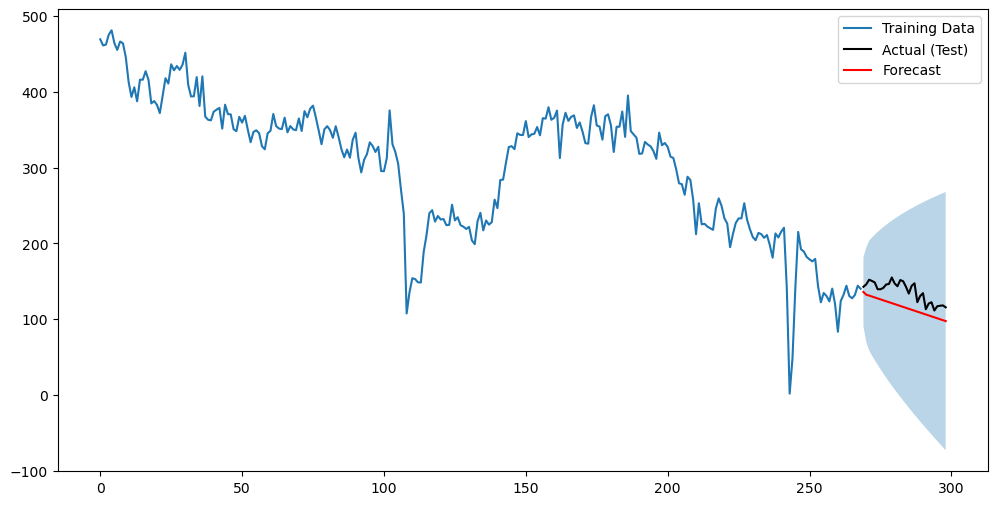

In [58]:
#Forecasting
forecast_prod = prod_fit.get_forecast(steps=len(test_prod))
mean_forecast_prod = forecast_prod.predicted_mean
conf_int_p = forecast_prod.conf_int()

#Predictions
plt.figure(figsize=(12,6))

# Training data
plt.plot(train_prod.index, train_prod, label="Training Data")

# Actual test data
plt.plot(test_prod.index, test_prod, label="Actual (Test)", color="black")

# Forecast
plt.plot(test_prod.index, mean_forecast_prod, label="Forecast", color="red")

# Confidence Interval
plt.fill_between(mean_forecast_prod.index, conf_int_p.iloc[:,0], conf_int_p.iloc[:,1], alpha=0.3)
plt.legend()
plt.show()



### **3c. Model Performance Evaluation**

In [59]:
#MAPE, MAE, & RMSE
mape_prod = np.mean(np.abs((test_prod.values - mean_forecast_prod) / test_prod.values)) * 100
mae_prod = np.mean(np.abs(test_prod.values - mean_forecast_prod))
rmse_prod = np.sqrt(np.mean((test_prod.values - mean_forecast_prod) ** 2))
print(f"MAPE: {mape_prod:.2f}%")
print("MAE:", mae_prod)
print("RMSE:", rmse_prod)

MAPE: 15.02%
MAE: 20.742305844082747
RMSE: 22.218410429593696


The prediction errors are high showcasing a need for additional modeling. ARIMA alone has been insufficient to forecast the data correctly. 

### **3d. VAR model**

In [60]:
#converting gas prices into quarterly frequency
gas_prices = gas_prices.rename(columns={'Dollar per gallon':'gas_prices'})
gas_prices['Date'] = pd.to_datetime(gas_prices['Date'])
gas_qtr = gas_prices.set_index('Date')

gas_qtr = gas_qtr.resample('QE').mean()
gas_qtr = gas_qtr.reset_index()


In [61]:
#Creating dataframe
var_prod = pd.DataFrame({
    'production': sales_qtr['Mn dollars'],
    'imports': imports['B651RC1Q027SBEA'],
    'disposable_income': dp_qtr['DSPIC96'],
    'interest_rate': int_qtr['FEDFUNDS %'],
    'gas_prices' : gas_qtr['gas_prices']
}).dropna()
var_prod

,production,imports,disposable_income,interest_rate,gas_prices
0,56.379,196.656,9833.933333,5.676667,1.433333
1,53.478,194.548,9950.166667,6.273333,1.566000
2,53.501,196.190,10081.500000,6.520000,1.561667
3,50.370,192.421,10149.000000,6.473333,1.537000
4,52.726,188.294,10229.833333,5.593333,1.475667
...,...,...,...,...,...
95,47.841,473.508,17416.700000,5.330000,3.480667
96,48.023,480.255,17596.200000,5.330000,3.355667
97,48.610,489.320,17701.000000,5.330000,3.678000
98,48.655,472.973,17755.333333,5.263333,3.481667


In [62]:
#Checking stationarity
def adf_test(series):
    result = adfuller(series)
    print(f'p-value: {result[1]}')

for col in var_prod.columns:
    print(col)
    adf_test(var_prod[col])

production
p-value: 0.09162874478657557
imports
p-value: 0.761017938623912
disposable_income
p-value: 0.9929222618695817
interest_rate
p-value: 0.000864345355432975
gas_prices
p-value: 0.35883134746690787


All p-values are above 0.05 and hence non-stationary.

In [63]:
var_prod_diff = var_prod.diff().dropna()

#Model VAR
model_p = VAR(var_prod_diff)

# Select optimal lag
lag_results_p = model_p.select_order(maxlags=10)
print(lag_results_p.summary())

# Fitting model using AIC
lag_p = lag_results_p.aic
var_model_p = model_p.fit(lag_p)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        15.73       15.87   6.764e+06       15.78
1        14.71      15.55*   2.448e+06       15.05
2        14.33       15.87   1.688e+06       14.95
3        13.94       16.17   1.150e+06      14.84*
4        13.99       16.92   1.244e+06       15.17
5       13.83*       17.46  1.106e+06*       15.29
6        14.01       18.34   1.413e+06       15.76
7        14.18       19.22   1.847e+06       16.21
8        14.30       20.03   2.352e+06       16.61
9        14.45       20.88   3.272e+06       17.04
10       14.34       21.47   3.715e+06       17.21
--------------------------------------------------


In [64]:
#Testing whether indicators help predict production
caus_prod = var_model_p.test_causality('production', ['imports', 'disposable_income', 'interest_rate','gas_prices'], kind='f')

print(caus_prod.summary())

Granger causality F-test. H_0: ['imports', 'disposable_income', 'interest_rate', 'gas_prices'] do not Granger-cause production. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         2.156          1.602   0.003 (20, np.int64(340))
---------------------------------------------------------


The Granger-causality test shows that p-value is 0.003 and this means economic indicators do impact production.

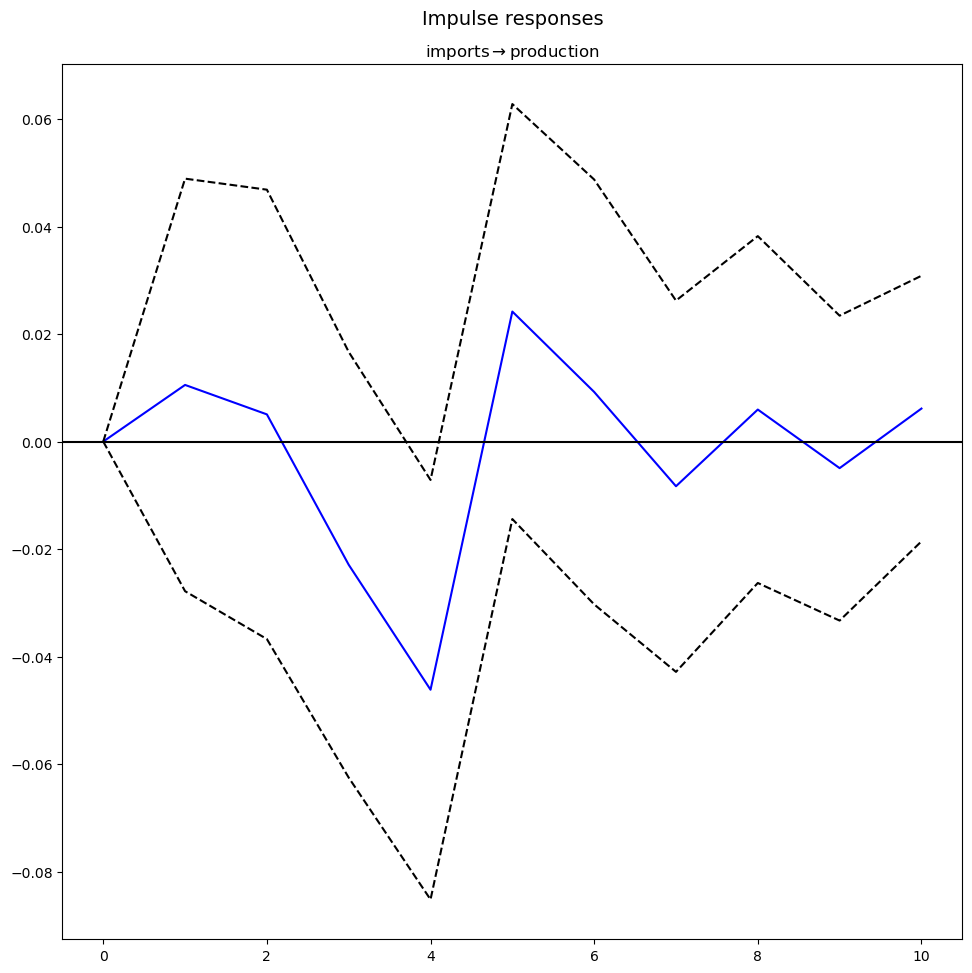

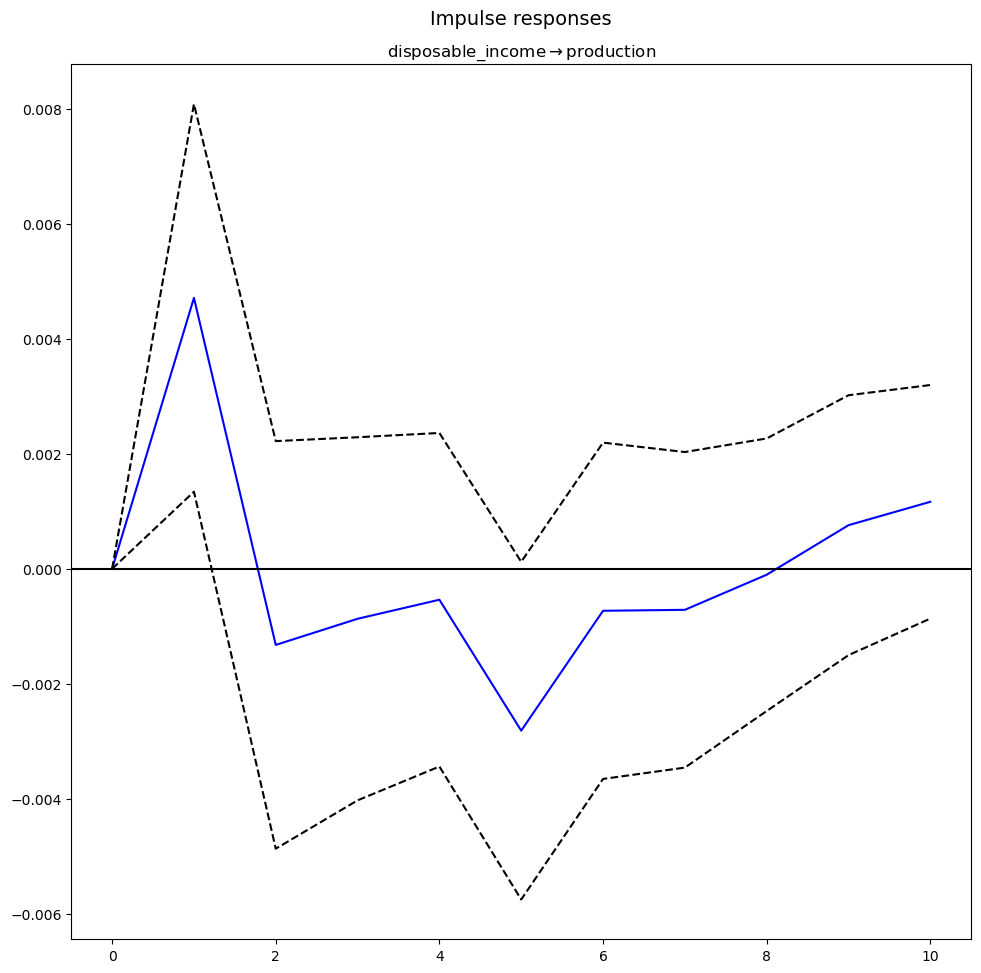

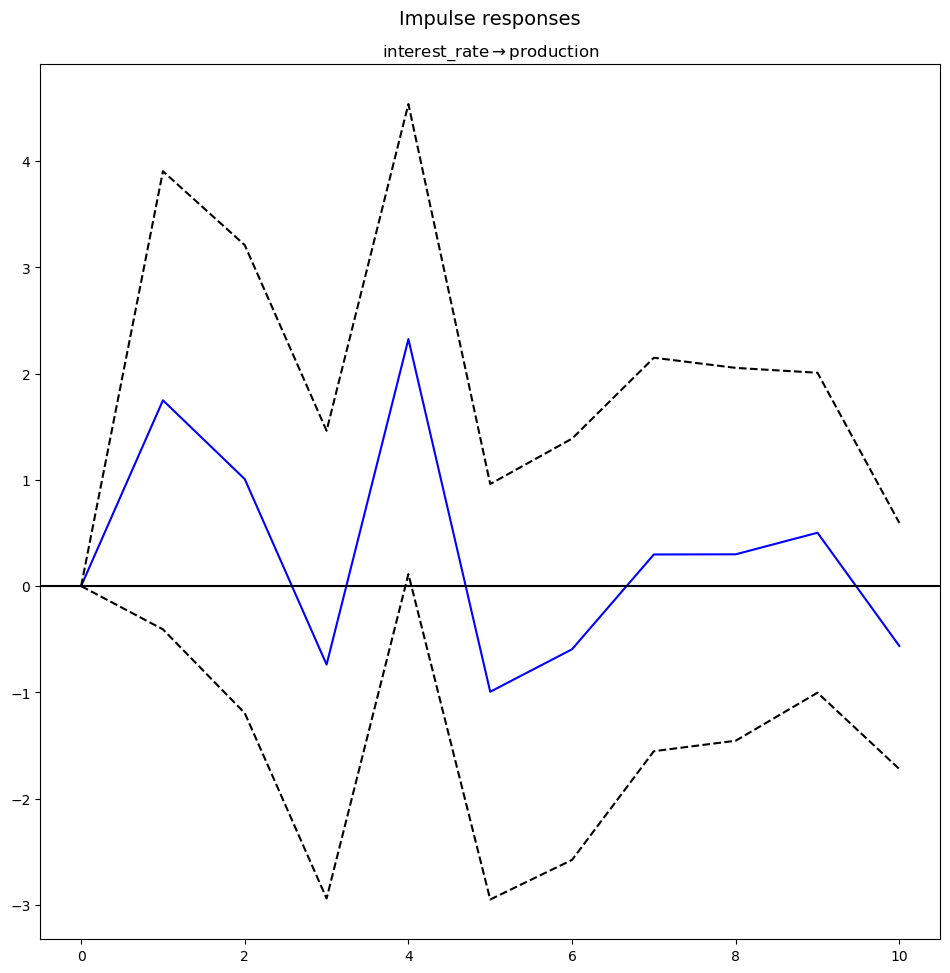

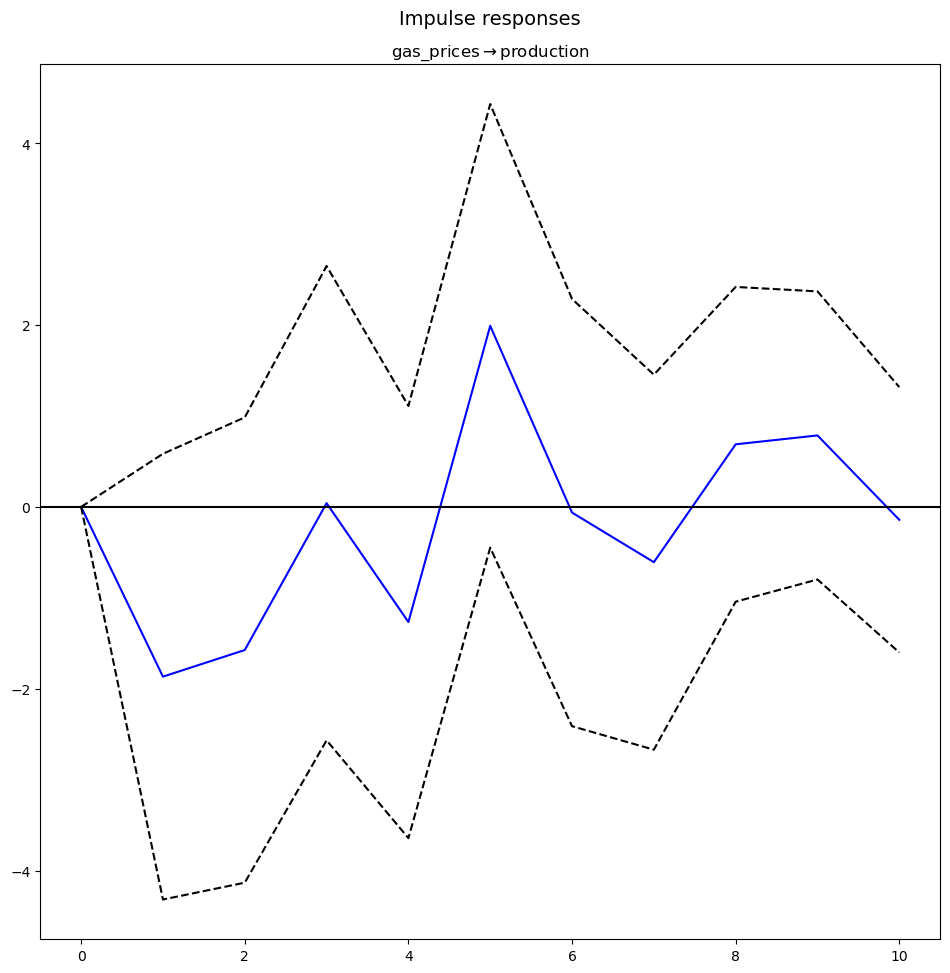

In [65]:
#checking response of economic indicators on production
irf = var_model_p.irf(10)

for var in ['imports', 'disposable_income', 'interest_rate','gas_prices']:
    irf.plot(impulse=var, response='production')

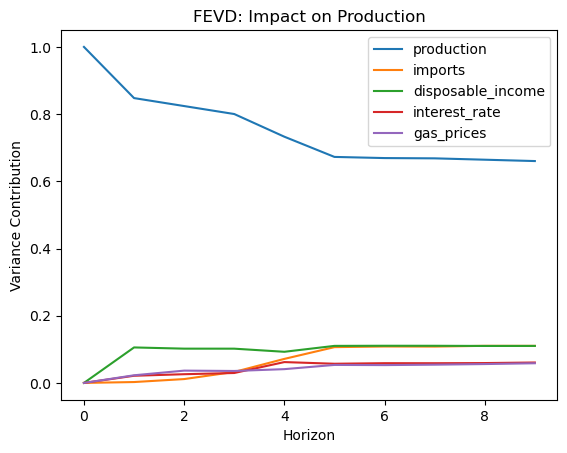

In [66]:
#Computing fevd for all economic indicators to check the extent of influence on sales.
fevd_p = var_model_p.fevd(10)
production_idx = var_model_p.names.index('production')
prod_fevd = fevd_p.decomp[production_idx]

for i, var in enumerate(var_model_p.names):
    plt.plot(prod_fevd[:, i], label=var)

plt.title("FEVD: Impact on Production")
plt.xlabel("Horizon")
plt.ylabel("Variance Contribution")
plt.legend()
plt.show()

The impact of economic indiactors is larger as compared to impact on sales where more than 80% influence came from sales past data whereas in production the influence of production's past data ranges from 70% to 100%. Among economic indicators, imports and gas prices show a prolonged impact on production and steadies after medium time period. Interest rate have next most impact on production. Disposable income has a very short lived influence on production data.

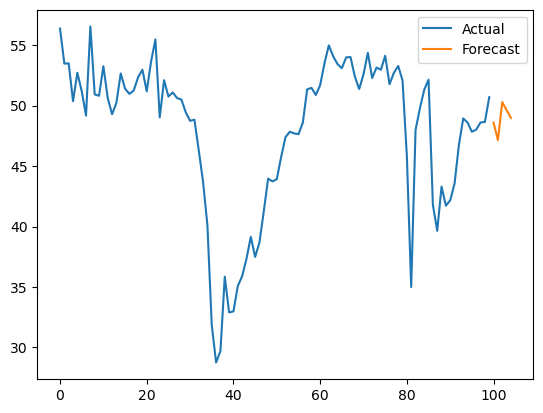

In [67]:
var_model_p = model_p.fit(lag_p)

lag = var_model_p.k_ar

last_values = var_prod_diff.values[-lag:]

forecast = var_model_p.forecast(y=last_values, steps=5)


forecast_df = pd.DataFrame(
    forecast,
    columns=var_model_p.names
)
prod_forecast = forecast_df['production']

last_actual = var_prod['production'].iloc[-1]

prod_forecast_actual = prod_forecast.cumsum() + last_actual

plt.plot(var_prod['production'], label='Actual')
plt.plot(
    range(len(var_prod), len(var_prod) + len(prod_forecast_actual)),
    prod_forecast_actual,
    label='Forecast'
)
plt.legend()
plt.show()

In [68]:
#MAPE, MAE, & RMSE
mape_prod_var = np.mean(np.abs((last_actual - prod_forecast_actual) / prod_forecast_actual)) * 100
mae_prod_var = np.mean(np.abs(last_actual - prod_forecast_actual))
rmse_prod_var = np.sqrt(np.mean((last_actual - prod_forecast_actual) ** 2))
print(f"MAPE: {mape_prod_var:.2f}%")
print("MAE:", mae_prod_var)
print("RMSE:", rmse_prod_var)

MAPE: 3.66%
MAE: 1.7679003354838998
RMSE: 2.0616631272382664


The addition to VAR model has significantly reduced the prediction errors signalling that VAR models have been able to efficiently capture the model's variability and predict future values. 

Conclusion:

This analysis identified that macroeconomic variables are not strong drivers of sales but play a significant role in explaining production dynamics. ARIMA-GARCH model was sufficient to predict the sales, where AR (1) model exhibited satisfactory results signifying high dependence of sales data on its preceding time values, and GARCH (1,1) model captured volatility effectively. VAR modeling was carried out on sales but impulse response and FEVD measures showed little to negligible significance and hence, ARIMA-GARCH forecasting was maintained. 

On the supply side, the absence of volatility sufficed the need of ARIMA model only. The VAR model identified that economic indicators have more impact on production than on sales. Further, forecasting was carried out by ARIMA only and later with VAR modeling and VAR modeling forecasting exhibited best results.

Hence it is concluded that sales are demand-driven and likely influenced by internal factors such as consumer behavior/sentiment, pricing, and seasonality, whereas production is more sensitive to supply-side factors such as imports, interest rates, and energy costs.
